# Exploratory Data Analysis - Fraud Data

This notebook contains EDA for the fraud dataset.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Path configurations updated for notebooks/ folder execution context
RAW_FRAUD_PATH = "../data/raw/Fraud_Data.csv"
RAW_IP_PATH = "../data/raw/IpAddress_to_Country.csv"
PROCESSED_DATA_DIR = "../data/processed/"

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")
print("Environment safely initialized.")

Environment safely initialized.


In [2]:
# Ingestion
df_fraud = pd.read_csv(RAW_FRAUD_PATH)

print("--- Initial E-commerce Structural Profile ---")
print(df_fraud.info())

# 1. Missing Values: Identify and justify removal/imputation
missing_counts = df_fraud.isnull().sum()
print("\nMissing Values Scan:\n", missing_counts)
# Justification: If missing count is 0, no imputation needed. Otherwise, drop rows for non-imputable tracking IDs.

# 2. Duplicates: Remove duplicate records to prevent evaluation bias
duplicates = df_fraud.duplicated().sum()
print(f"\nDuplicate records found: {duplicates}")
if duplicates > 0:
    df_fraud = df_fraud.drop_duplicates()
    print("Duplicates cleanly purged.")

# 3. Data Type Corrections: Parse string timestamps into proper Datetime properties
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])

print("\nData type casting confirmed.")

--- Initial E-commerce Structural Profile ---
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB
None

Missing Values Scan:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age      

--- Class Imbalance Profile ---
Class 0 (0=Legit, 1=Fraud): 136961 records (90.64%)
Class 1 (0=Legit, 1=Fraud): 14151 records (9.36%)


C:\Users\Guyatu\AppData\Local\Temp\ipykernel_25768\1339493976.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df_fraud, palette='Set2')


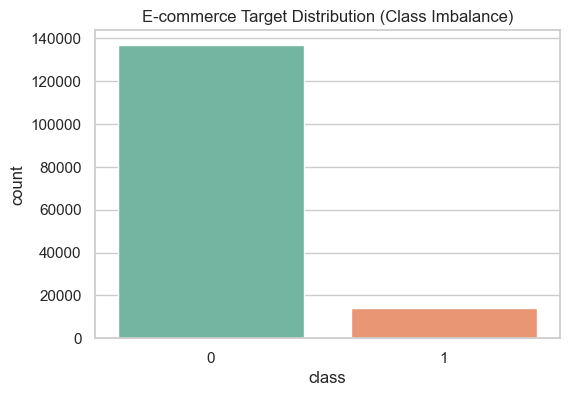

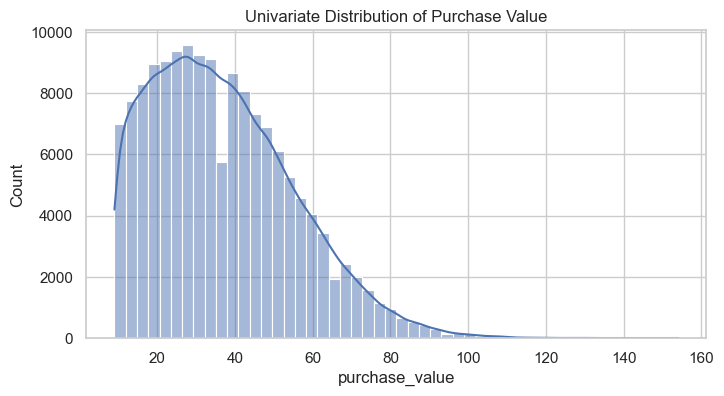

C:\Users\Guyatu\AppData\Local\Temp\ipykernel_25768\1339493976.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='age', data=df_fraud, palette='Set1')


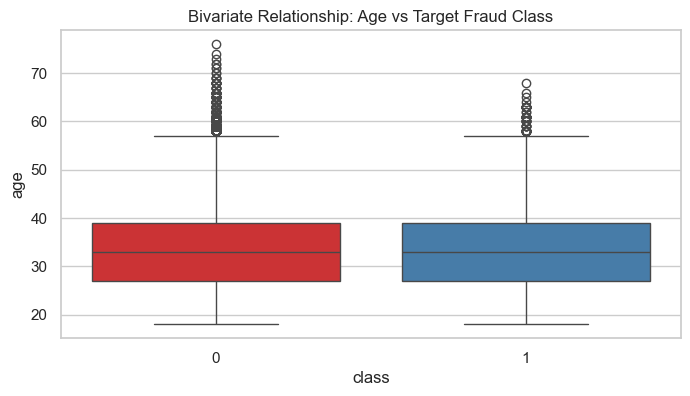

In [3]:
# 1. Quantify Class Imbalance
class_counts = df_fraud['class'].value_counts()
class_pct = df_fraud['class'].value_counts(normalize=True) * 100
print("--- Class Imbalance Profile ---")
for cls, cnt, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    print(f"Class {cls} (0=Legit, 1=Fraud): {cnt} records ({pct:.2f}%)")

# Visualize Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df_fraud, palette='Set2')
plt.title("E-commerce Target Distribution (Class Imbalance)")
plt.savefig("../notebooks/ecommerce_class_imbalance.png")
plt.show()

# 2. Univariate Distribution (Purchase Value)
plt.figure(figsize=(8, 4))
sns.histplot(df_fraud['purchase_value'], bins=50, kde=True)
plt.title("Univariate Distribution of Purchase Value")
plt.savefig("../notebooks/purchase_value_dist.png")
plt.show()

# 3. Bivariate Relationship (Age vs. Target Class)
plt.figure(figsize=(8, 4))
sns.boxplot(x='class', y='age', data=df_fraud, palette='Set1')
plt.title("Bivariate Relationship: Age vs Target Fraud Class")
plt.savefig("../notebooks/age_vs_target.png")
plt.show()

In [4]:
# 1. Convert IPv4 addresses (represented as floats/strings) to 64-bit integer format
df_fraud['ip_address_int'] = df_fraud['ip_address'].astype(np.int64)

# Load country range dataset
df_ip = pd.read_csv(RAW_IP_PATH)
df_ip['lower_bound_ip_address'] = df_ip['lower_bound_ip_address'].astype(np.int64)
df_ip['upper_bound_ip_address'] = df_ip['upper_bound_ip_address'].astype(np.int64)

# 2. Sort components to prepare for an optimized interval lookup merge using pandas merge_asof
df_ip = df_ip.sort_values(by='lower_bound_ip_address').reset_index(drop=True)
df_fraud = df_fraud.sort_values(by='ip_address_int').reset_index(drop=True)

df_merged = pd.merge_asof(
    df_fraud,
    df_ip,
    left_on='ip_address_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# 3. Validation: If the IP address falls outside the mapped upper bound, label it as 'Unknown'
df_merged.loc[df_merged['ip_address_int'] > df_merged['upper_bound_ip_address'], 'country'] = 'Unknown'
df_merged['country'] = df_merged['country'].fillna('Unknown')

# 4. Analyze Fraud Patterns by Country
country_fraud = df_merged.groupby('country')['class'].agg(['count', 'sum']).rename(columns={'sum': 'fraud_cases'})
country_fraud['fraud_rate'] = country_fraud['fraud_cases'] / country_fraud['count']
top_fraud_countries = country_fraud.sort_values(by='fraud_cases', ascending=False).head(10)

print("\n--- Top 10 Countries by Total Fraud Cases ---")
print(top_fraud_countries)


--- Top 10 Countries by Total Fraud Cases ---
                   count  fraud_cases  fraud_rate
country                                          
United States      58049         5551    0.095626
Unknown            21966         1883    0.085723
China              12038         1043    0.086642
Japan               7306          715    0.097865
United Kingdom      4490          477    0.106236
Korea Republic of   4162          380    0.091302
Canada              2975          348    0.116975
France              3161          300    0.094907
Brazil              2961          270    0.091185
Germany             3646          262    0.071860


In [5]:
# 1. Temporal feature extraction
df_merged['hour_of_day'] = df_merged['purchase_time'].dt.hour
df_merged['day_of_week'] = df_merged['purchase_time'].dt.dayofweek

# 2. time_since_signup: Duration elapsed in seconds between signup and purchase execution
df_merged['time_since_signup'] = (df_merged['purchase_time'] - df_merged['signup_time']).dt.total_seconds()

# 3. Transaction velocity/frequency metrics within device tracking spaces
df_merged['device_tx_count'] = df_merged.groupby('device_id')['user_id'].transform('count')
df_merged['ip_tx_count'] = df_merged.groupby('ip_address')['user_id'].transform('count')

print("Behavioral and velocity features engineered successfully.")

Behavioral and velocity features engineered successfully.


In [6]:
# 1. One-hot encode nominal categorical attributes
categorical_cols = ['source', 'browser', 'sex']
df_transformed = pd.get_dummies(df_merged, columns=categorical_cols, drop_first=True)

# 2. Normalize numerical features using StandardScaler
numeric_features = ['purchase_value', 'age', 'hour_of_day', 'day_of_week', 'time_since_signup', 'device_tx_count', 'ip_tx_count']
scaler = StandardScaler()
df_transformed[numeric_features] = scaler.fit_transform(df_transformed[numeric_features])

# Isolate feature matrix from target label ('class')
feature_cols = numeric_features + [col for col in df_transformed.columns if col.startswith(tuple(categorical_cols))]
X = df_transformed[feature_cols]
y = df_transformed['class']

# 3. Stratified Partition Split: Enforce a clean train/test split BEFORE resampling to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Pre-Resampling Class Balance in Training Set: {np.bincount(y_train)}")

# 4. Handle Imbalance: Apply SMOTE strictly on the training set partitions
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Post-Resampling Class Balance (SMOTE): {np.bincount(y_train_resampled)}")

# Save processed splits out to disk
X_train_resampled.to_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_X_train.csv"), index=False)
y_train_resampled.to_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_y_train.csv"), index=False)
X_test.to_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_X_test.csv"), index=False)
y_test.to_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_y_test.csv"), index=False)
print("E-commerce datasets saved successfully.")

Pre-Resampling Class Balance in Training Set: [109568  11321]
Post-Resampling Class Balance (SMOTE): [109568 109568]
E-commerce datasets saved successfully.
